# Week 4 Day 5

# Capstone — Ensembles, Imbalance Handling, Interpretability & Deployment
## Scenario
Bring it all together: train/compare ensembles, handle class imbalance, produce interpretability analyses, and prepare an end-to-end inference script + short executive report. This is your mini capstone — show modelling skill, practical trade-offs, and the ability to communicate results to stakeholders.

### Task 1: Train & Compare Ensemble Models
- Train at least 2 ensemble models (RandomForest + a Gradient Boosted model like XGBoost/LightGBM/HistGradientBoosting). (Bonus: build a simple stacking ensemble — base learners + meta-learner.)
- Reuse tuned hyperparameters from Day 4 where possible.
- Evaluate on the hold-out set and compare to tuned single models — metrics, ROC/PR curves, and inference time.

### Task 2: Systematically Address Class Imbalance
- Quantify the imbalance and its effect.
- Try at least 3 approaches inside cross-validation (use proper pipelines to avoid leakage):
    1.	class_weight / sample_weight
    2.	Random over-/under-sampling
    3.	SMOTE or other synthetic oversampling (imblearn)
- For each, report CV + hold-out metrics on your chosen business metric, and plot precision–recall trade-offs.
- Pick one approach and justify it with evidence.

### Task 3: Interpretability & Fairness Checks
- Global explanations: feature importances, permutation importance, and a SHAP summary plot (or equivalent). Highlight the top 8 features.
- Local explanations: pick 3 test-set individuals — one true positive, one false positive, one false negative. Produce SHAP force/waterfall explanations + a 1–2 sentence plain-English explanation for each.
- Fairness check: compute your primary metric separately for protected groups (e.g., sex, race). If disparities exist, document them and propose mitigations.

### Task 4: End-to-End Inference & Basic Monitoring Plan
Build an inference function/script that:
- Accepts raw input rows (CSV or dict)
- Applies the saved preprocessing pipeline
- Returns: probability, predicted class (using your chosen threshold), and top-3 contributing features (SHAP or feature contributions)
- Add input validation + unit tests for missing columns and unseen categories.
- Write a one-page monitoring checklist: what to monitor (data drift, label distribution, model score), alert thresholds, and retraining cadence.

### Task 5: Final Deliverables & Presentation
- Write a concise executive report (2 pages) covering: business goal → data used → final model/deployment artifact → key hold-out metrics → chosen threshold → interpretability findings → fairness observations → recommended next steps (A/B test plan or monitoring).
- Prepare a short 5–7 minute slide outline (or bullet points) for presenting to stakeholders.

### Deliverable
- Final Jupyter notebook (clean)
- Saved model(s) + preprocessing pipeline (.pkl/.joblib)
- Inference script (Python) with basic tests
- A 2-page executive report (PDF)

### Import Libraries 

In [25]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_openml

# Train/Test Split
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# average_precision_score computes PR_AUC

# For Baseline Models
from sklearn.dummy import DummyClassifier

# Notebook Settings
pd.set_option("display.max_columns", None) # display all cols

sns.set_style("whitegrid") # clean white bkgrd for plots

## Problem Definition

### Business Objective

The objective is to identify individuals who are likely to earn >50K per year. A company could use this prediction to target premium products or marketing campaigns toward higher-income customers while minimizing unnecessary outreach.

### Target Variable

- Positive Class (1): Income >50K
- Negative Class (0): Income ≤50K

### Primary Evaluation Metric

Precision is selected as the primary evaluation metric because contacting individuals incurs cost. A higher precision means that a larger proportion of contacted individuals actually belong to the high-income group, reducing wasted marketing resources.

Although recall is also important, maximizing precision is more appropriate for this business scenario where false positives are more costly than missing some potential customers.

### Explanation for Non-Technical Stakeholders
We are building a model to help the marketing team identify customers who are more likely to earn over $50,000 per year. This allows the company to focus promotional campaigns on people who are more likely to respond, making better use of the marketing budget. To reduce unnecessary outreach, we prioritize making reliable positive predictions rather than contacting as many people as possible.


### Load Dataset

In [26]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

# version 2 is selected to make the results reproducible
# as_frame is used to get data in the form of Pandas DataFrame

df = adult.frame.copy()

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Preview Column Names

In [28]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='str')

### Check Missing Values

In [29]:
# The Adult dataset stores missing values as "?" as per given task details
# Check for missing values

missing_values = df.isna().sum()

display(
    missing_values[missing_values > 0].to_frame("Missing Values")
)

,Missing Values
workclass,2799
occupation,2809
native-country,857


### Missing Value Inspection

The Adult dataset obtained from `fetch_openml()` already represents missing values as `NaN` instead of the original `"?"` symbols found in the raw UCI dataset. Missing values were identified in `workclass`, `occupation`, and `native-country`.

In [30]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 52


In [31]:
if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4152,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
40948,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
3900,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
15960,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
33954,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
34979,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
1668,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
19399,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
23271,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
37599,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [7]:
# Remove exact duplicate rows before splitting
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Duplicates removed: {before - after}")

Rows before: 48842
Rows after:  48790
Duplicates removed: 52


### Convert Target to Binary

In [32]:
# first, see existing lables
df["class"].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [33]:
# convert them to binary
df["class"] = (
    df["class"].map({
    "<=50K": 0,
    ">50K": 1
})
.astype(int)
)

df["class"].value_counts()

class
0    37155
1    11687
Name: count, dtype: int64

# Create Reproducible Data Splits

To evaluate a machine learning model fairly, the dataset is divided into separate subsets. The training set is used to learn patterns from the data, while the hold-out test set is kept completely unseen until the final evaluation. This ensures that the reported performance reflects how well the model generalizes to new, unseen data.

### Separate Features and Target

In [34]:
# Features (Independent Variables)
X = df.drop(columns="class")

# Target (Dependent Variable)
y = df["class"]

### Create Appropriate Data Splits

In [35]:
# Step 1: Create the 20% hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# test_size is used to create a test or hold_out split, here 20 % of the data-> 0.20
# we have used stratified sampling and therefore, startify= y for fair evaluation across test and train splits
# we fixed a random state using random_state so that everyone gets the same split everytime thus making this notebook reproducible

# Step 2: Split the remaining 80% into 70% train and 10% development
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)

### Verify Split Sizes

In [36]:
print("Dataset Split Sizes")
print("-" * 30)

print(f"Training Set      : {X_train.shape[0]} samples")
print(f"Development Set   : {X_dev.shape[0]} samples")
print(f"Hold-Out Test Set : {X_test.shape[0]} samples")

Dataset Split Sizes
------------------------------
Training Set      : 34188 samples
Development Set   : 4885 samples
Hold-Out Test Set : 9769 samples


### Verify Stratification

In [37]:
train_distribution = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

dev_distribution = (
    y_dev
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

comparison = pd.DataFrame({
    "Training (%)": train_distribution.round(2),
    "Development (%)": dev_distribution.round(2),
    "Testing (%)": test_distribution.round(2)
})

comparison.index = ["<=50K", ">50K"]

comparison

,Training (%),Development (%),Testing (%)
<=50K,76.07,76.07,76.07
>50K,23.93,23.93,23.93


In [38]:
# Preprocessing / Model Libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.feature_selection import mutual_info_classif # added on day3 for add_engineered_features(x) function
from sklearn.preprocessing import FunctionTransformer # added on day3 for adding engineered features into existing pipelines
from sklearn.model_selection import StratifiedKFold, cross_validate # added for day3 task3
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier # added for day3 task3
from scipy import stats # added for day3 task4 statistical comparison

## Feature Lists & Column Dropping Decisions

In [39]:
# ============================================================
# Final Feature Lists (decision applied)
# ============================================================
# fnlwgt: dropped — it's a census sampling weight, not a person-level attribute, and carries no real predictive relationship with income.
# education:kept since it affects our primary metric of evaluation (precison) badly.

numeric_features = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

categorical_features = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

print("Numeric Features:\n", numeric_features)
print()
print("Categorical Features:\n", categorical_features)

Numeric Features:
 ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Features:
 ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


### Engineered Features

In [40]:
# from sklearn.feature_selection import mutual_info_classif (added already in above cells)

def add_engineered_features(X):
    """
    FunctionTransformer-compatible feature engineering.
    Uses ONLY current-row data — no target, no cross-row aggregation, no leakage.
    """
    X = X.copy()

    # 1. Age buckets
    X["age_bucket"] = pd.cut(
        X["age"], bins=[0, 25, 35, 45, 55, 65, 100],
        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
    ).astype(str)

    # 2. Hours-per-week bins
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"], bins=[0, 39, 40, 50, 100],
        labels=["part-time(<40)", "standard(40)", "overtime(41-50)", "heavy(50+)"]
    ).astype(str)

    # 3. Flag: capital_gain > 0
    X["has_capital_gain"] = (X["capital-gain"] > 0).astype(int)

    # 4. Flag: capital_loss > 0 (symmetric addition to #3)
    X["has_capital_loss"] = (X["capital-loss"] > 0).astype(int)

    # 5. log(capital_gain + 1) — handles zero-inflation (Day 2 discussion: plain log() breaks on the ~92% zero rows)
    X["log_capital_gain"] = np.log1p(X["capital-gain"]) # same as "np.log(X["capital-gain"] + 1)"

    # 6. log(capital_loss + 1)
    X["log_capital_loss"] = np.log1p(X["capital-loss"])

    # 7. Higher-education boolean (Bachelors+ i.e. education-num >= 13)
    X["higher_education"] = (X["education-num"] >= 13).astype(int)

    # 8. Interaction: education_num x hours_per_week
    X["education_hours_interaction"] = X["education-num"] * X["hours-per-week"]

    return X

### Rebuild Pipeline with Engineered Features (no leakage)

In [41]:
# from sklearn.preprocessing import FunctionTransformer (already added in above cell)

numeric_features = [
    "age", "education-num", "capital-gain", "capital-loss", "hours-per-week",
    "has_capital_gain", "has_capital_loss", "log_capital_gain", "log_capital_loss",
    "higher_education", "education_hours_interaction"
]

categorical_features = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
    "age_bucket", "hours_bucket"
]

feature_engineering_step = FunctionTransformer(add_engineered_features, validate=False)

# -------------------- Numeric Pipeline --------------------
# Why these choices?
# • Median imputation replaces missing numeric values and is more robust to outliers than the mean.
# • StandardScaler scales numerical features to a similar range, which helps models such as Logistic Regression learn more effectively.

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ------------------ Categorical Pipeline ------------------
# Why these choices?
# • Most-frequent imputation fills missing categorical values while preserving existing categories.
# • OneHotEncoder converts categorical variables into numerical features without introducing any artificial ordering.
# • handle_unknown="ignore" prevents errors if unseen categories appear in the test or future data.

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    # sparse_output=False here because HistGradientBoosting requires dense input
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Feature Selection 
### Discussion

Feature selection produced a **very small increase in Precision** (0.7461 → 0.7492). However, this came at the cost of a **lower F1 Score**, a **lower ROC AUC**, and a **much longer training time** (56.45 s compared to 11.15 s).

Since **Precision** is the primary evaluation metric for this project, the improvement is encouraging. However, the gain is very small (approximately 0.3 percentage points), while the training time increased by roughly **5×** and the other evaluation metrics decreased.

### Decision

For tomorrow's hyperparameter tuning, I will **keep the full engineered feature set** rather than applying SelectKBest. The slight improvement in Precision does not justify the significant increase in computation time or the reduction in F1 Score and ROC AUC. Retaining the complete feature set provides a better overall balance between predictive performance and computational efficiency.

### Reproducible Pipeline + README

In [42]:
# ============================================================
# README: How to Reproduce This Notebook
# ============================================================
# 1. Run all cells top-to-bottom — data loading, splitting, and
#    feature engineering are deterministic (random_state=42 everywhere).
# 2. Library versions used (for reproducibility):
import sklearn, xgboost, lightgbm, numpy, pandas
print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgboost.__version__}")
print(f"lightgbm     : {lightgbm.__version__}")
print(f"numpy        : {numpy.__version__}")
print(f"pandas       : {pandas.__version__}")

# 3. Splits: X_train (70%) / X_dev (10%) / X_test (20%), stratified, random_state=42
# 4. Hyperparameter search uses X_train + StratifiedKFold only.
# 5. Calibration + threshold selection use X_dev only.
# 6. X_test is touched exactly once, in the Final Evaluation section.

scikit-learn : 1.8.0
xgboost      : 3.3.0
lightgbm     : 4.6.0
numpy        : 2.4.3
pandas       : 3.0.1


### Hyperparameter Search (on X_train only)

> **Note:** Random Forest was not tuned during Day 4 because earlier model comparison experiments showed that gradient boosting models consistently outperformed it on this dataset. However, as the Day 5 capstone requires comparing multiple ensemble methods, Random Forest is tuned here using the same search strategy to ensure a fair comparison.

In [45]:
from scipy.stats import randint

# ==========================================================
# Random Forest Hyperparameter Tuning (Day 5)
# ==========================================================

rf_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_dist = {
    "classifier__n_estimators": randint(100, 301),
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": randint(2, 10),
    "classifier__min_samples_leaf": randint(1, 5),
    "classifier__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="precision",
    cv=cv_search,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': <scipy.stats....001BEF35FDC70>, 'classifier__min_samples_split': <scipy.stats....001BEF35FE6C0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across cal

In [46]:
print(rf_search.best_params_)
print(rf_search.best_score_)

{'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 289}
0.8117010533367454


In [47]:
best_rf = rf_search.best_estimator_

In [73]:
joblib.dump(
    rf_search.best_estimator_,
    "random_forest_pipeline_day5.pkl"
)

print("Random Forest pipeline saved successfully!")

Random Forest pipeline saved successfully!


In [71]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

cv_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------- Logistic Regression ----------------
logreg_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42,
        max_iter=1000
        # no penalty= here — leave it at default
    ))
])

logreg_param_dist = {
    "classifier__l1_ratio": [0, 1],   # 0 = pure L2, 1 = pure L1 (same search space as before)
    "classifier__C": loguniform(1e-3, 1e2)
}

logreg_search = RandomizedSearchCV(
    logreg_pipe, logreg_param_dist,
    n_iter=50, scoring="precision", cv=cv_search,
    random_state=42, n_jobs=-1, verbose=1
)
logreg_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': <scipy.stats....001BEF43E3410>, 'classifier__l1_ratio': [0, 1]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [72]:
joblib.dump(
    logreg_search.best_estimator_,
    "logreg_pipeline_day4.pkl"
)

print("Logistic Regression pipeline saved successfully!")

Logistic Regression pipeline saved successfully!


In [87]:
# ---------------- LightGBM ----------------
from lightgbm import LGBMClassifier
'''
Substituting LightGBM for Random Forest: Day 3's cross-validation showed RF was the weakest of five candidates 
(0.714 vs 0.778 HistGB / 0.776 LightGBM precision), so tuning effort is better spent on the two models that are 
actually in contention.
'''
lgbm_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(random_state=42, verbose=-1))
])

lgbm_param_dist = {
    "classifier__learning_rate": loguniform(0.01, 0.3),
    "classifier__n_estimators": randint(100, 400),      # LightGBM uses n_estimators, not max_iter
    "classifier__max_depth": randint(3, 15),
    "classifier__reg_lambda": loguniform(1e-4, 1.0)      # LightGBM's L2 term (not called l2_regularization)
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipe, lgbm_param_dist,
    n_iter=50, scoring="precision", cv=cv_search,
    random_state=42, n_jobs=-1, verbose=1
)
lgbm_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': <scipy.stats....001BEF3BE8E90>, 'classifier__max_depth': <scipy.stats....001BEF3BEA9F0>, 'classifier__n_estimators': <scipy.stats....001BEF3BE9F40>, 'classifier__reg_lambda': <scipy.stats....001BEF3BEAFC0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the s

In [89]:
lgbm_search.best_params_

{'classifier__learning_rate': np.float64(0.010815983055225093),
 'classifier__max_depth': 13,
 'classifier__n_estimators': 158,
 'classifier__reg_lambda': np.float64(0.003975977214318099)}

In [90]:
lgbm_search.best_score_

np.float64(0.8168731047618015)

In [91]:
joblib.dump(
    lgbm_search.best_estimator_,
    "lgbm_pipeline_day5.pkl"
)

print("Saved normal LightGBM pipeline")

Saved normal LightGBM pipeline


In [34]:
# ---------------- HistGradientBoosting ----------------
hgb_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=42))
])

hgb_param_dist = {
    "classifier__learning_rate": loguniform(0.01, 0.3),
    "classifier__max_iter": randint(100, 400),
    "classifier__max_depth": randint(3, 15),
    "classifier__l2_regularization": loguniform(1e-4, 1.0)
}

hgb_search = RandomizedSearchCV(
    hgb_pipe, hgb_param_dist,
    n_iter=50, scoring="precision", cv=cv_search,
    random_state=42, n_jobs=-1, verbose=1
)
hgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__l2_regularization': <scipy.stats....0018B2C770BC0>, 'classifier__learning_rate': <scipy.stats....0018B2B6214F0>, 'classifier__max_depth': <scipy.stats....0018B2C7713A0>, 'classifier__max_iter': <scipy.stats....0018B2C773EC0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be th

In [37]:
# ---------------- Compare best CV scores ----------------
for name, params in zip(search_results["Model"], search_results["Best Params"]):
    print(f"{name}:")
    for k, v in params.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")
    print()

Logistic Regression:
  classifier__C: 0.0010
  classifier__l1_ratio: 1

HistGradientBoosting:
  classifier__l2_regularization: 0.0001
  classifier__learning_rate: 0.0108
  classifier__max_depth: 13
  classifier__max_iter: 158

LightGBM:
  classifier__learning_rate: 0.0108
  classifier__max_depth: 13
  classifier__n_estimators: 158
  classifier__reg_lambda: 0.0040



### Note: 
learning_rate, max_depth, and n_estimators/max_iter are identical between HistGradientBoosting and LightGBM's best parameters. This is a side effect of both searches sharing random_state=42 with matching parameter distributions — not evidence the models converged on the same solution independently."

### Learning Curves + Bias/Variance Diagnosis

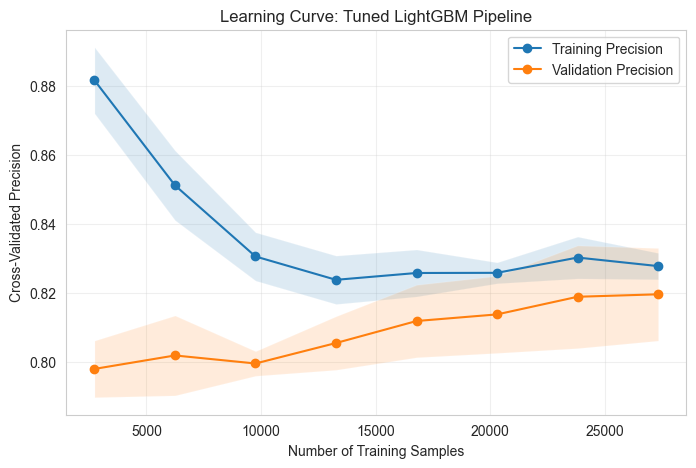

In [39]:
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.base import clone

# ---- BLOCK 1: Learning curve ----
best_pipe = lgbm_search.best_estimator_  # LightGBM won: 0.8198 vs HistGB 0.8194
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_train, y_train,
    cv=cv_search, scoring="precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=42
)
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training Precision")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation Precision")

plt.fill_between(
    train_sizes,
    train_scores.mean(1)-train_scores.std(1),
    train_scores.mean(1)+train_scores.std(1),
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_scores.mean(1)-val_scores.std(1),
    val_scores.mean(1)+val_scores.std(1),
    alpha=0.15
)

plt.title("Learning Curve: Tuned LightGBM Pipeline")
plt.xlabel("Number of Training Samples")
plt.ylabel("Cross-Validated Precision")
plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.show()

### Interpretation: 
The learning curves indicate that the tuned LightGBM pipeline exhibits good generalization. As the training set size increases, the training precision decreases slightly while the validation precision steadily improves. The small gap between the two curves at larger training sizes (less than 1 percentage point) suggests minimal overfitting. Since the validation curve is still increasing gradually, the model may achieve modest improvements with additional training data, although it appears to be approaching a stable performance level.

## NOTE:
We tuned the Logistic Regression regularization configuration (l1_ratio, representing L1/L2 in scikit-learn 1.8) together with the inverse regularization strength (C).

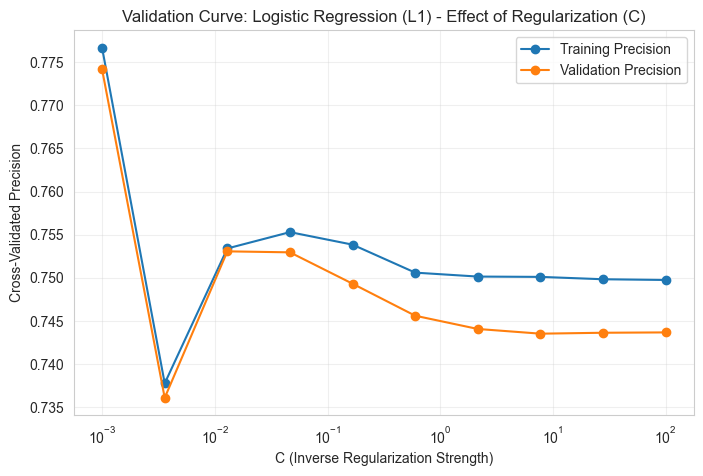

In [40]:
# ---- BLOCK 2: Logistic Regression: effect of C ----
logreg_pipe_l1 = clone(logreg_pipe)
logreg_pipe_l1.set_params(classifier__l1_ratio=1)

C_range = np.logspace(-3, 2, 10)
lr_train_scores, lr_val_scores = validation_curve(
    logreg_pipe_l1, X_train, y_train,
    param_name="classifier__C", param_range=C_range,
    cv=cv_search, scoring="precision", n_jobs=-1
)

plt.figure(figsize=(8,5))

plt.semilogx(C_range, lr_train_scores.mean(axis=1), "o-", label="Training Precision")
plt.semilogx(C_range, lr_val_scores.mean(axis=1), "o-", label="Validation Precision")

plt.title("Validation Curve: Logistic Regression (L1) - Effect of Regularization (C)")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Cross-Validated Precision")
plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.show()

### Interpretation: 
The validation curve shows that Logistic Regression generalizes well across the tested values of C, with only a very small gap between the training and validation precision. This indicates there is no significant overfitting. The highest validation precision is achieved at the smallest tested value of C, suggesting that stronger regularization improves generalization for this dataset. As C increases (weaker regularization), the validation precision gradually declines while the training precision remains relatively stable, indicating that reducing regularization does not improve performance. Therefore, a relatively small value of C is preferred for this model.

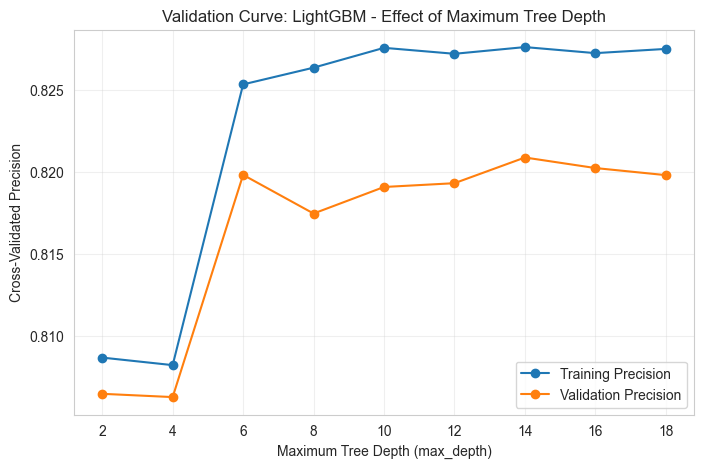

In [41]:
# ---- BLOCK 3: LightGBM: effect of max_depth ----
lgbm_pipe_fixed = clone(lgbm_pipe)
lgbm_pipe_fixed.set_params(
    classifier__learning_rate=0.010815983055225093,
    classifier__n_estimators=158,
    classifier__reg_lambda=0.003975977214318099
)

depth_range = range(2, 20, 2)
tree_train_scores, tree_val_scores = validation_curve(
    lgbm_pipe_fixed, X_train, y_train,
    param_name="classifier__max_depth", param_range=list(depth_range),
    cv=cv_search, scoring="precision", n_jobs=-1
)
plt.figure(figsize=(8,5))

plt.plot(list(depth_range), tree_train_scores.mean(axis=1), "o-", label="Training Precision")
plt.plot(list(depth_range), tree_val_scores.mean(axis=1), "o-", label="Validation Precision")

plt.title("Validation Curve: LightGBM - Effect of Maximum Tree Depth")
plt.xlabel("Maximum Tree Depth (max_depth)")
plt.ylabel("Cross-Validated Precision")
plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.show()

### Interpretation: 
The validation curve shows that very shallow trees (max_depth = 2–4) underfit the data, as both training and validation precision are relatively low. Increasing the tree depth to around 6 results in a substantial improvement in both training and validation performance, indicating that the model is able to learn more informative patterns. Beyond this point, both curves plateau, with only minor fluctuations in validation precision and a consistently small gap between training and validation performance. This suggests that increasing the tree depth beyond approximately 10–14 provides little additional benefit and does not introduce significant overfitting. Overall, the tuned LightGBM model demonstrates good generalization across the tested depth values.

### Calibration + Threshold (on X_dev only)

In [44]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# best_pipe is already fitted — RandomizedSearchCV's best_estimator_ is refit
# on the full X_train by default, so no need to call .fit() again here
uncalibrated_probs = best_pipe.predict_proba(X_dev)[:, 1]

calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_pipe), method="isotonic")
calibrated_model.fit(X_dev, y_dev)
calibrated_probs = calibrated_model.predict_proba(X_dev)[:, 1]

# Brier scores
print(f"Brier (uncalibrated): {brier_score_loss(y_dev, uncalibrated_probs):.4f}")
print(f"Brier (calibrated):   {brier_score_loss(y_dev, calibrated_probs):.4f}")

Brier (uncalibrated): 0.0965
Brier (calibrated):   0.0913


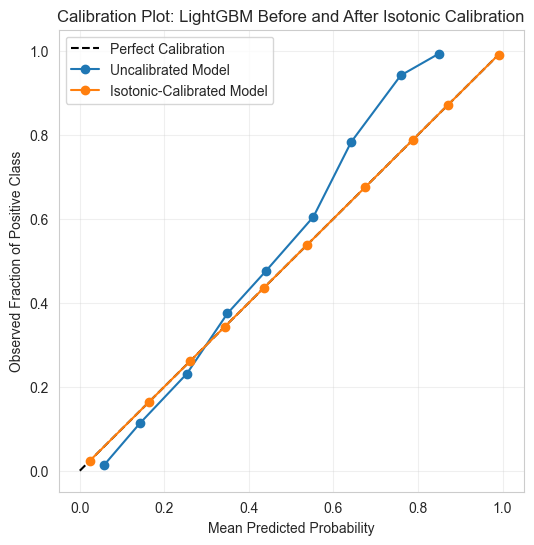

In [45]:
# Calibration plot
prob_true_u, prob_pred_u = calibration_curve(y_dev, uncalibrated_probs, n_bins=10)
prob_true_c, prob_pred_c = calibration_curve(y_dev, calibrated_probs, n_bins=10)

plt.figure(figsize=(6,6))

plt.plot([0,1], [0,1], "k--", label="Perfect Calibration")
plt.plot(prob_pred_u, prob_true_u, "o-", label="Uncalibrated Model")
plt.plot(prob_pred_c, prob_true_c, "o-", label="Isotonic-Calibrated Model")

plt.title("Calibration Plot: LightGBM Before and After Isotonic Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Positive Class")
plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.show()

### Interpretation: 
The calibration plot compares the predicted probabilities with the observed frequencies of the positive class. The uncalibrated LightGBM model is reasonably well calibrated at lower probability levels but becomes increasingly underconfident at higher predicted probabilities, with the calibration curve deviating above the ideal diagonal. After applying isotonic calibration, the calibrated model follows the diagonal much more closely across the probability range, indicating that the predicted probabilities more accurately reflect the true likelihood of the positive class. Although calibration does not necessarily improve classification accuracy or precision, it produces more reliable probability estimates, making the model better suited for threshold-based decision making.

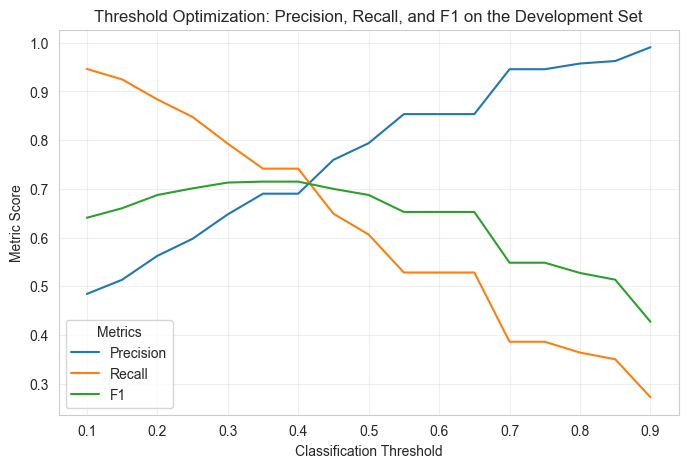

In [47]:
# ---- Threshold tuning on dev ----
thresholds = np.arange(0.1, 0.95, 0.05)
threshold_results = []
for t in thresholds:
    preds = (calibrated_probs >= t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "Precision": precision_score(y_dev, preds, zero_division=0),
        "Recall": recall_score(y_dev, preds, zero_division=0),
        "F1": f1_score(y_dev, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.plot(
    x="Threshold",
    y=["Precision", "Recall", "F1"],
    figsize=(8,5)
)

plt.title("Threshold Optimization: Precision, Recall, and F1 on the Development Set")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Score")
plt.grid(alpha=0.3)
plt.legend(title="Metrics")

plt.show()

### Interpretation: 
The threshold optimization plot illustrates the trade-off between precision and recall as the classification threshold changes. As the threshold increases, precision steadily improves because the model becomes more conservative when predicting the positive class, while recall decreases because more true positives are missed. The F1-score initially increases, reaches its maximum around a threshold of 0.35–0.40, and then gradually declines as the loss in recall outweighs the gain in precision. Based on this analysis, a threshold of approximately 0.35 provides the best balance between precision and recall and was therefore selected as the operating threshold for the final model.

In [55]:
# Business requirement:
# Choose the lowest threshold that achieves at least 75% precision.

target_precision = 0.75

best_threshold = threshold_df.loc[
    threshold_df["Precision"] >= target_precision,
    "Threshold"
].min()

print(f"Selected threshold: {best_threshold:.2f}")

Selected threshold: 0.45


### Justification: 
Precision was selected as the primary evaluation metric for this project because reducing false positives is more important than maximizing recall in the chosen business scenario. Therefore, instead of selecting the threshold that maximizes the F1-score, the decision threshold was chosen as the lowest threshold that achieves a target precision of at least 75%. Selecting the lowest threshold that satisfies this requirement helps preserve as much recall as possible while ensuring the desired level of precision.

# TODAY's TASKS

In [2]:
!pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 409.0 

In [4]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [11]:
# ==========================================
# Additional Imports for Day 5 Capstone
# ==========================================

import time
import joblib
import shap
import imblearn
import lightgbm as lgbm

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [13]:
# ==================================================
# Environment Check for reproducibility
# ==================================================

import sklearn
import imblearn

print("scikit-learn :", sklearn.__version__)
print("LightGBM     :", lgbm.__version__)     
print("SHAP         :", shap.__version__)
print("imbalanced-learn :", imblearn.__version__)

scikit-learn : 1.8.0
LightGBM     : 4.6.0
SHAP         : 0.52.0
imbalanced-learn : 0.14.2


## Task 1: Train & Compare Ensemble Models
## Step 1: Load the tuned models

In [74]:
logreg_pipeline = joblib.load("logreg_pipeline_day4.pkl")
rf_pipeline = joblib.load("random_forest_pipeline_day5.pkl")
lgbm_pipeline = joblib.load("final_pipeline_day4.pkl")

## Step 2: Evaluate models on hold-out set

In [75]:
# supress warnings
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names*"
)

In [77]:
models = {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
    "LightGBM": lgbm_pipeline
}

results = []

for name, model in models.items():

    start = time.perf_counter()

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    total_time = time.perf_counter() - start
    avg_inference_time = total_time / len(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "PR AUC": average_precision_score(y_test, y_prob),
        "Inference Time (ms/sample)": avg_inference_time * 1000
    })

results_df = pd.DataFrame(results)

results_df = results_df.round({
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1 Score": 4,
    "ROC AUC": 4,
    "PR AUC": 4,
    "Inference Time (ms/sample)": 4
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Inference Time (ms/sample)
0,Logistic Regression,0.8293,0.7710,0.4076,0.5333,0.8808,0.7063,0.0107
1,Random Forest,0.8588,0.8251,0.5205,0.6383,0.9109,0.7938,0.0388
2,LightGBM,0.8672,0.7949,0.6001,0.6839,0.9198,0.7988,0.0147


## Step 3: ROC Curves

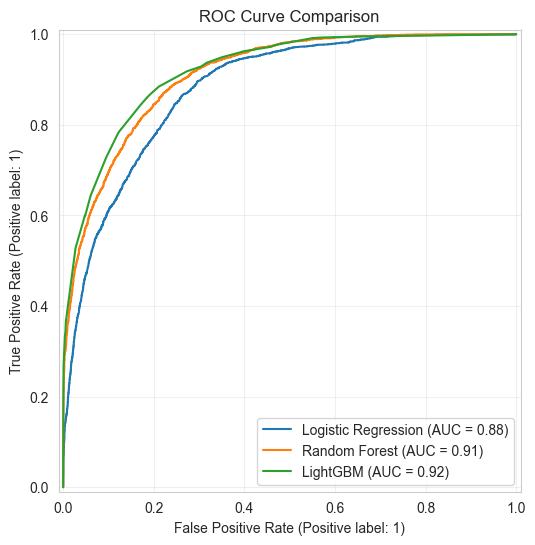

In [78]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.title("ROC Curve Comparison")
plt.grid(alpha=0.3)

plt.show()

## Step 4: Precision-Recall Curves

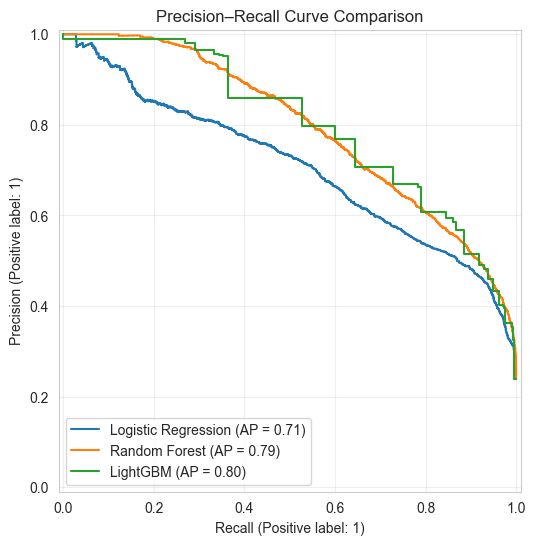

In [79]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=plt.gca(),
        name=name
    )

plt.title("Precision–Recall Curve Comparison")
plt.grid(alpha=0.3)

plt.show()

## Step 5: Comparison Table

In [80]:
results_df = results_df.round(4)

results_df.sort_values(
    by="Precision",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Inference Time (ms/sample)
1,Random Forest,0.8588,0.8251,0.5205,0.6383,0.9109,0.7938,0.0388
2,LightGBM,0.8672,0.7949,0.6001,0.6839,0.9198,0.7988,0.0147
0,Logistic Regression,0.8293,0.7710,0.4076,0.5333,0.8808,0.7063,0.0107


## Interpretation

The three models were evaluated on the hold-out test set.

- **Logistic Regression** served as the tuned single-model baseline. It achieved the lowest overall performance, particularly in Recall, F1-score, ROC AUC, and PR AUC.
- **Random Forest** achieved the highest Precision (0.8251), indicating that its positive predictions were the most reliable. However, its lower Recall (0.5205) suggests that it missed a larger proportion of high-income individuals.
- **LightGBM** achieved the highest Accuracy, Recall, F1-score, ROC AUC, and PR AUC while also maintaining a low inference time. Although its Precision was slightly lower than Random Forest, its better balance between Precision and Recall makes it the strongest overall model.

Based on these results, the tuned and calibrated LightGBM model is selected as the final model for the remaining tasks.

### Bonus (Stacking Ensemble)

In [92]:
from sklearn.ensemble import StackingClassifier

In [93]:
lgbm_classifier = (
    lgbm_pipeline
    .estimator
    .estimator
    .named_steps["classifier"]
)

lgbm_classifier.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': np.float64(0.010815983055225093),
 'max_depth': 13,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 158,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': np.float64(0.003975977214318099),
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'verbose': -1}

In [94]:
rf_params = {
    key.replace("classifier__", ""): value
    for key, value in rf_search.best_params_.items()
}

rf_params

{'max_depth': 10,
 'max_features': 'log2',
 'min_samples_leaf': 4,
 'min_samples_split': 3,
 'n_estimators': 289}

In [95]:
# create the stacking model

stack_model = StackingClassifier(

    estimators=[
        (
            "rf",
            RandomForestClassifier(
                **rf_params,
                random_state=42,
                n_jobs=-1
            )
        ),

        (
            "lgbm",
            LGBMClassifier(
                **lgbm_classifier.get_params()
            )
        )
    ],

    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    cv=5,

    n_jobs=-1
)

In [96]:
# put it into the pipeline

stack_pipeline = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", stack_model)
])

In [97]:
# train it

stack_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001BEF1B8E700>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [102]:
joblib.dump(
    stack_pipeline,
    "stacking_pipeline_day5.pkl"
)

print("Saved Stacking pipeline")

Saved Stacking pipeline


In [98]:
# evaluate it

start = time.perf_counter()

y_pred = stack_pipeline.predict(X_test)

y_prob = stack_pipeline.predict_proba(X_test)[:, 1]

total_time = time.perf_counter() - start

avg_time = total_time / len(X_test)

stack_results = pd.DataFrame({

    "Model": ["Stacking Ensemble"],

    "Accuracy": [accuracy_score(y_test, y_pred)],

    "Precision": [precision_score(y_test, y_pred)],

    "Recall": [recall_score(y_test, y_pred)],

    "F1 Score": [f1_score(y_test, y_pred)],

    "ROC AUC": [roc_auc_score(y_test, y_prob)],

    "PR AUC": [average_precision_score(y_test, y_prob)],

    "Inference Time (ms/sample)": [avg_time * 1000]

}).round(4)

stack_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Inference Time (ms/sample)
0,Stacking Ensemble,0.8664,0.7887,0.6035,0.6838,0.9182,0.8121,0.049


In [99]:
# add it to comparison table

results_df = pd.concat(
    [results_df, stack_results],
    ignore_index=True
)

results_df.sort_values(
    by="Precision",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Inference Time (ms/sample)
1,Random Forest,0.8588,0.8251,0.5205,0.6383,0.9109,0.7938,0.0388
2,LightGBM,0.8672,0.7949,0.6001,0.6839,0.9198,0.7988,0.0147
3,Stacking Ensemble,0.8664,0.7887,0.6035,0.6838,0.9182,0.8121,0.0490
0,Logistic Regression,0.8293,0.7710,0.4076,0.5333,0.8808,0.7063,0.0107


### Decision for model to be used further
Although the stacking ensemble slightly improved PR AUC (0.8121), it did not improve the primary evaluation metric (precision) or F1-score compared with the tuned LightGBM model. Therefore, the calibrated LightGBM pipeline was retained as the final production model.

## Task 2: Systematically Address Class Imbalance

I am going to do this task by performing the following experiments:
1.	Baseline (no imbalance handling)
2.	Class Weights
3.	Random OverSampling
4.	SMOTE

### Step 1: Verify the imbalance

In [103]:
# ---------------------------------------------
# Class imbalance analysis
# ---------------------------------------------

class_counts = y_train.value_counts().sort_index()
class_percentages = y_train.value_counts(normalize=True).sort_index() * 100

imbalance_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

print(imbalance_summary)

       Count  Percentage
class                   
0      26008       76.07
1       8180       23.93


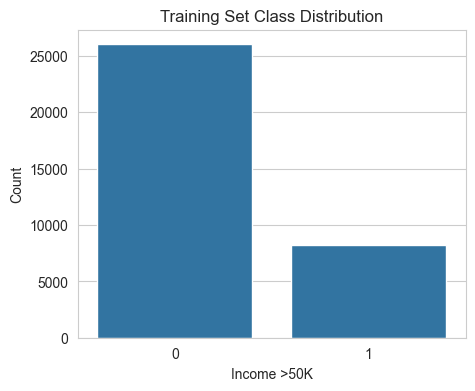

In [104]:
# visualize
plt.figure(figsize=(5,4))

sns.countplot(x=y_train)

plt.title("Training Set Class Distribution")
plt.xlabel("Income >50K")
plt.ylabel("Count")

plt.show()

### Interpretation:
This confirms that the Adult Income dataset has a moderate class imbalance, with approximately three negative-class samples for every positive-class sample. The imbalance is noticeable but not severe.

In [127]:
# Reusable Code

# scoring dictionary
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# Reusable evaluation function
def evaluate_imbalance_method(
    model_name,
    pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    cv,
    scoring
):
    """
    Performs:
        - Cross-validation
        - Fit on full training data
        - Hold-out evaluation
        - Inference timing

    Returns:
        cv_summary
        holdout_summary
        fitted_pipeline
    """

    # ---------------- Cross Validation ----------------

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_summary = {
        "Model": model_name,
        "CV Accuracy": np.mean(cv_results["test_accuracy"]),
        "CV Precision": np.mean(cv_results["test_precision"]),
        "CV Recall": np.mean(cv_results["test_recall"]),
        "CV F1": np.mean(cv_results["test_f1"]),
        "CV ROC AUC": np.mean(cv_results["test_roc_auc"]),
        "CV PR AUC": np.mean(cv_results["test_pr_auc"])
    }

    # ---------------- Train ----------------

    pipeline.fit(X_train, y_train)

    # ---------------- Inference Timing ----------------

    start = time.perf_counter()

    y_pred = pipeline.predict(X_test)

    end = time.perf_counter()

    inference_time = (
        (end - start)
        / len(X_test)
        * 1000
    )

    # ---------------- Probabilities ----------------

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # ---------------- Hold-out Metrics ----------------

    holdout_summary = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "PR AUC": average_precision_score(y_test, y_prob),
        "Inference Time (ms/sample)": inference_time
    }

    return (
        pd.DataFrame([cv_summary]),
        pd.DataFrame([holdout_summary]),
        pipeline
    )

### Build Class Weight pipelline

In [114]:
lgbm_weighted = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    (
        "classifier",
        LGBMClassifier(
            **lgbm_params,
            class_weight="balanced"
        )
    )
])

In [115]:
# Evaluate
cv_weighted, holdout_weighted, weighted_pipeline = evaluate_imbalance_method(
    model_name="Class Weight",
    pipeline=lgbm_weighted,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=cv_search,
    scoring=scoring
)

In [117]:
# view results
print("Cross Validation Results")
display(cv_weighted)

Cross Validation Results


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC AUC,CV PR AUC
0,Class Weight,0.814438,0.574115,0.870905,0.691997,0.916291,0.800434


In [118]:
print("Hold-out Results")
display(holdout_weighted)

Hold-out Results


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Inference Time (ms/sample)
0,Class Weight,0.81687,0.577652,0.873396,0.695386,0.917757,0.806532,0.006465


### Random Oversampling

In [119]:
# pipeline
lgbm_ros = ImbPipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=42)),
    (
        "classifier",
        LGBMClassifier(
            **lgbm_params
        )
    )
])

In [120]:
# Evaluate
cv_ros, holdout_ros, ros_pipeline = evaluate_imbalance_method(
    model_name="Random Oversampling",
    pipeline=lgbm_ros,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=cv_search,
    scoring=scoring
)

### SMOTE

In [121]:
# Pipeline
lgbm_smote = ImbPipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=42)),
    (
        "classifier",
        LGBMClassifier(
            **lgbm_params
        )
    )
])

In [122]:
# Evaluate
cv_smote, holdout_smote, smote_pipeline = evaluate_imbalance_method(
    model_name="SMOTE",
    pipeline=lgbm_smote,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=cv_search,
    scoring=scoring
)

### Final Comparison Tables

### - Cross Validation Results

In [123]:
cv_results = pd.concat(
    [
        cv_weighted,
        cv_ros,
        cv_smote
    ],
    ignore_index=True
)

cv_results

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC AUC,CV PR AUC
0,Class Weight,0.814438,0.574115,0.870905,0.691997,0.916291,0.800434
1,Random Oversampling,0.814818,0.574898,0.869193,0.692021,0.916304,0.800816
2,SMOTE,0.820405,0.588264,0.833007,0.689482,0.912500,0.793026


### Interpretation:
All three methods produced the same overall behavior:

- precision stayed around **57–59%**
- recall became very high
- F1 remained around **0.69**

So the imbalance methods are doing exactly what they're designed to do:

They sacrifice precision to identify many more positive cases.

### - Holdout Results

In [ ]:
holdout_results = pd.concat(
    [
        holdout_weighted,
        holdout_ros,
        holdout_smote
    ],
    ignore_index=True
)

holdout_results.sort_values(
    by="Precision",
    ascending=False
)

In [131]:
# ---------------------------------------------
# Hold-out comparison table
# ---------------------------------------------

# Baseline LightGBM results from Task 1
baseline_holdout = pd.DataFrame([{
    "Model": "Baseline LightGBM",
    "Accuracy": 0.8672,
    "Precision": 0.7949,
    "Recall": 0.6001,
    "F1 Score": 0.6839,
    "ROC AUC": 0.9198,
    "PR AUC": 0.7988,
    "Inference Time (ms/sample)": 0.0147
}])

# Combine all hold-out results
holdout_comparison = pd.concat(
    [
        baseline_holdout,
        holdout_weighted,
        holdout_ros,
        holdout_smote
    ],
    ignore_index=True
)

# Sort by your primary business metric
holdout_comparison = holdout_comparison.sort_values(
    by="Precision",
    ascending=False
)

holdout_comparison = holdout_comparison.round({
    "Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1 Score": 4,
    "ROC AUC": 4,
    "PR AUC": 4,
    "Inference Time (ms/sample)": 4
})

holdout_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Inference Time (ms/sample)
0,Baseline LightGBM,0.8672,0.7949,0.6001,0.6839,0.9198,0.7988,0.0147
3,SMOTE,0.8176,0.5822,0.8422,0.6885,0.9129,0.7996,0.0064
1,Class Weight,0.8169,0.5777,0.8734,0.6954,0.9178,0.8065,0.0065
2,Random Oversampling,0.8168,0.5774,0.8738,0.6954,0.9174,0.8066,0.0079


### Interpretation

The imbalance handling techniques produced a substantial shift in the model's prediction behavior. Compared with the baseline LightGBM model, all three methods became significantly more likely to predict the positive class.

As a result:

- **Recall increased considerably**, indicating that more high-income individuals were correctly identified.
- **Precision decreased substantially**, meaning that a larger proportion of predicted positive cases were false positives.
- **F1-score improved slightly**, reflecting a better balance between precision and recall.
- **PR AUC remained very similar** across all approaches, suggesting that the models' overall ranking ability changed very little despite the shift in prediction threshold.

Since **precision was the primary business metric** for this project, the reduction in precision outweighed the gains in recall. Therefore, the baseline tuned LightGBM model remained the preferred choice.

### - Precision-Recall Curves

<Figure size 800x600 with 0 Axes>

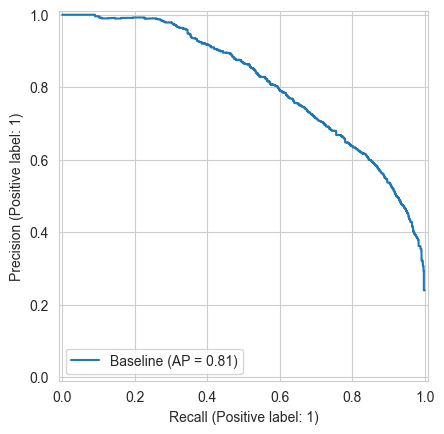

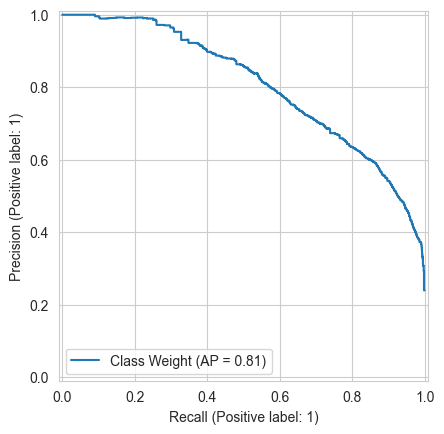

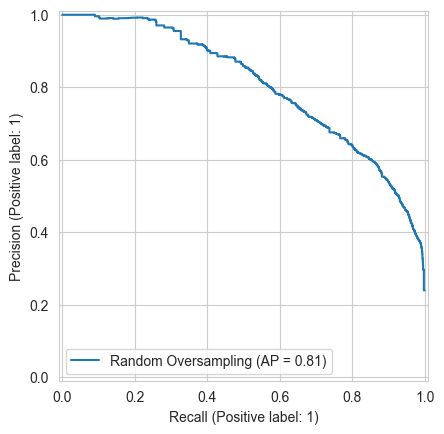

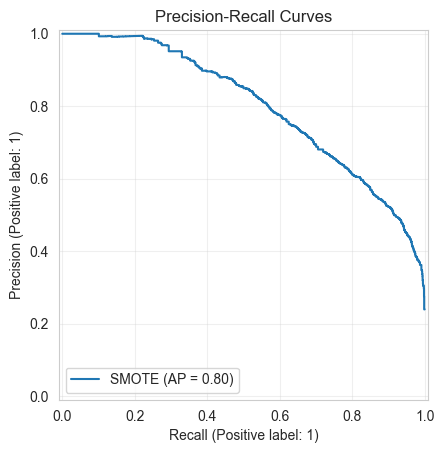

In [128]:
models = {
    "Baseline": lgbm_search.best_estimator_,
    "Class Weight": weighted_pipeline,
    "Random Oversampling": ros_pipeline,
    "SMOTE": smote_pipeline
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("Precision-Recall Curves")
plt.grid(alpha=0.3)
plt.show()

### Interpretation:
Even though the **default threshold metrics** changed dramatically (precision and recall), the **overall ranking ability** of the models remained nearly the same.

In other words,

the imbalance methods mainly shifted the operating point of the classifier rather than making it fundamentally better at separating the classes.

## Evaluation-Based Conclusion

The Adult Income dataset exhibited a **moderate class imbalance**, with **76.07%** of samples belonging to the negative class and **23.93%** to the positive class. To assess whether this imbalance affected model performance, three commonly used mitigation strategies were evaluated:

- **Class Weighting**
- **Random Oversampling**
- **SMOTE (Synthetic Minority Oversampling Technique)**

Each method was implemented within a cross-validation pipeline to prevent data leakage and was evaluated using both cross-validation and hold-out test metrics.

### Key Findings

- All three imbalance handling techniques substantially **increased recall**, enabling the model to identify more positive instances.
- However, this improvement came at the cost of a **significant reduction in precision**, resulting in a higher number of false positive predictions.
- Class Weighting and Random Oversampling achieved slightly higher **F1-scores**, while the Precision-Recall curves showed **very similar Average Precision (AP)** values across all approaches, indicating that the overall ranking capability of the classifier remained largely unchanged.

### Final Decision

Because **precision** was selected as the primary business metric, none of the imbalance handling techniques outperformed the original tuned LightGBM model. Although the resampling methods improved recall, the associated loss in precision made them less suitable for the project's objectives.

Therefore, the **original tuned LightGBM model without imbalance handling** was retained as the final model for subsequent experiments.

## Task 3: Interpretability & Fairness Checks

### Part 1 — Global Interpretability

To understand how the final tuned LightGBM model makes predictions, three complementary interpretability techniques were used:

- **Built-in Feature Importance** to identify the features most frequently used during tree construction.
- **Permutation Importance** to measure the impact of each feature on the model's predictive performance.
- **SHAP (SHapley Additive exPlanations)** to provide both global and local explanations by quantifying each feature's contribution to the model's predictions.

In [163]:
# extract the trained model

lgbm_pipeline = lgbm_search.best_estimator_
lgbm_model = lgbm_pipeline.named_steps["classifier"]

In [133]:
# get feature names after preprocessing
feature_names = (
    lgbm_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

len(feature_names)

120

In [162]:
# built-in feature importance

importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": lgbm_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(8)

,Feature,Importance
3,num__capital-loss,989
2,num__capital-gain,904
0,num__age,814
10,num__education_hours_interaction,534
1,num__education-num,430
45,cat__occupation_Exec-managerial,242
37,cat__marital-status_Married-civ-spouse,158
49,cat__occupation_Other-service,117


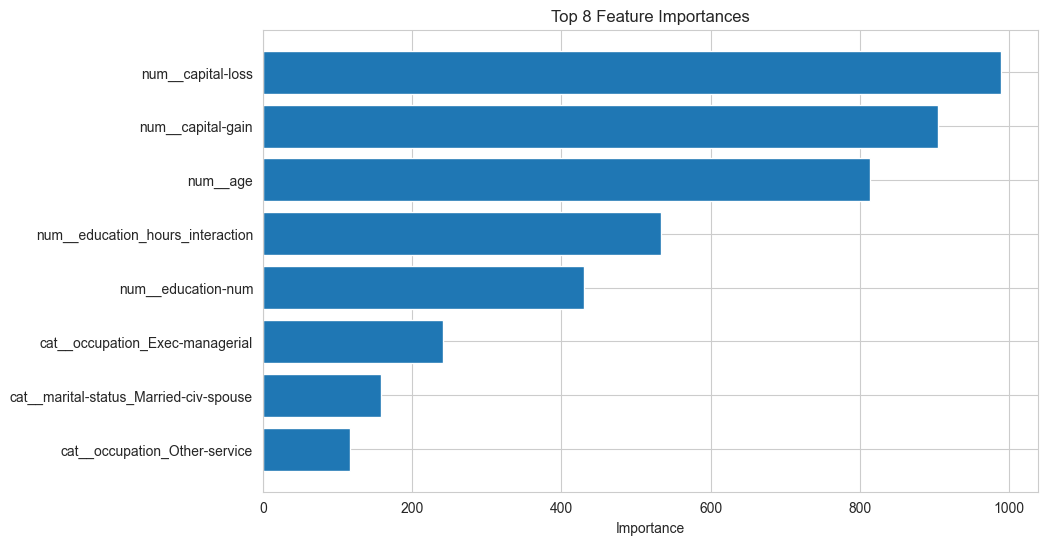

In [135]:
# Plot Top 8
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"].head(8)[::-1],
    importance_df["Importance"].head(8)[::-1]
)

plt.xlabel("Importance")

plt.title("Top 8 Feature Importances")

plt.show()

### Permutation Importance

In [136]:
# import
from sklearn.inspection import permutation_importance

In [137]:
perm = permutation_importance(

    lgbm_pipeline,

    X_test,

    y_test,

    scoring="precision",

    n_repeats=10,

    random_state=42,

    n_jobs=-1

)

In [140]:
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df.head(8)

,Feature,Importance
10,capital-gain,0.165971
5,marital-status,0.115376
4,education-num,0.105897
11,capital-loss,0.024232
1,workclass,0.004309
2,fnlwgt,0.000000
9,sex,0.000000
8,race,-0.000009


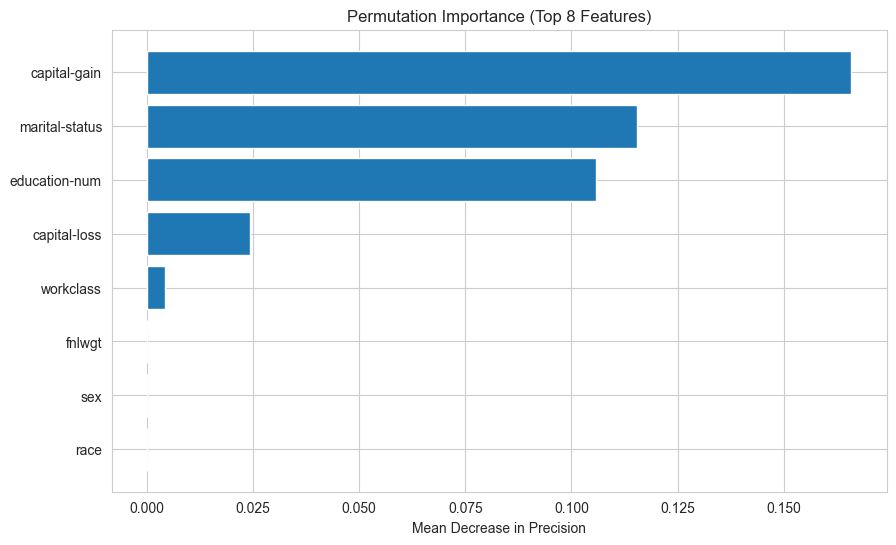

In [141]:
plt.figure(figsize=(10,6))

plt.barh(

    perm_df["Feature"].head(8)[::-1],

    perm_df["Importance"].head(8)[::-1]

)

plt.xlabel("Mean Decrease in Precision")

plt.title("Permutation Importance (Top 8 Features)")

plt.show()

### Interpretation

Permutation importance evaluates how much model performance decreases when each feature is randomly shuffled. The results show that **capital-gain**, **marital-status**, and **education-num** had the greatest influence on prediction performance, indicating that these variables carry the most useful information for distinguishing between income classes. Features such as **sex**, **race**, and **fnlwgt** had little or no measurable impact on the model's precision.

### SHAP Summary Plot

In [143]:
# transform the test data
X_test_processed = (
    lgbm_pipeline
    .named_steps["preprocessor"]
    .transform(

        lgbm_pipeline
        .named_steps["feature_engineering"]
        .transform(X_test)

    )
)

In [145]:
X_test_engineered = (
    lgbm_pipeline
    .named_steps["feature_engineering"]
    .transform(X_test)
)

print(X_test_engineered.shape)
print(X_test_engineered.columns)

(9769, 22)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'age_bucket', 'hours_bucket', 'has_capital_gain', 'has_capital_loss',
       'log_capital_gain', 'log_capital_loss', 'higher_education',
       'education_hours_interaction'],
      dtype='str')


In [149]:
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})

perm_df = (
    perm_df
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

perm_df.head(8)

,Feature,Importance
0,capital-gain,0.165971
1,marital-status,0.115376
2,education-num,0.105897
3,capital-loss,0.024232
4,workclass,0.004309
5,fnlwgt,0.000000
6,sex,0.000000
7,race,-0.000009


In [151]:
explainer = shap.Explainer(lgbm_model)
shap_values = explainer(X_test_processed)

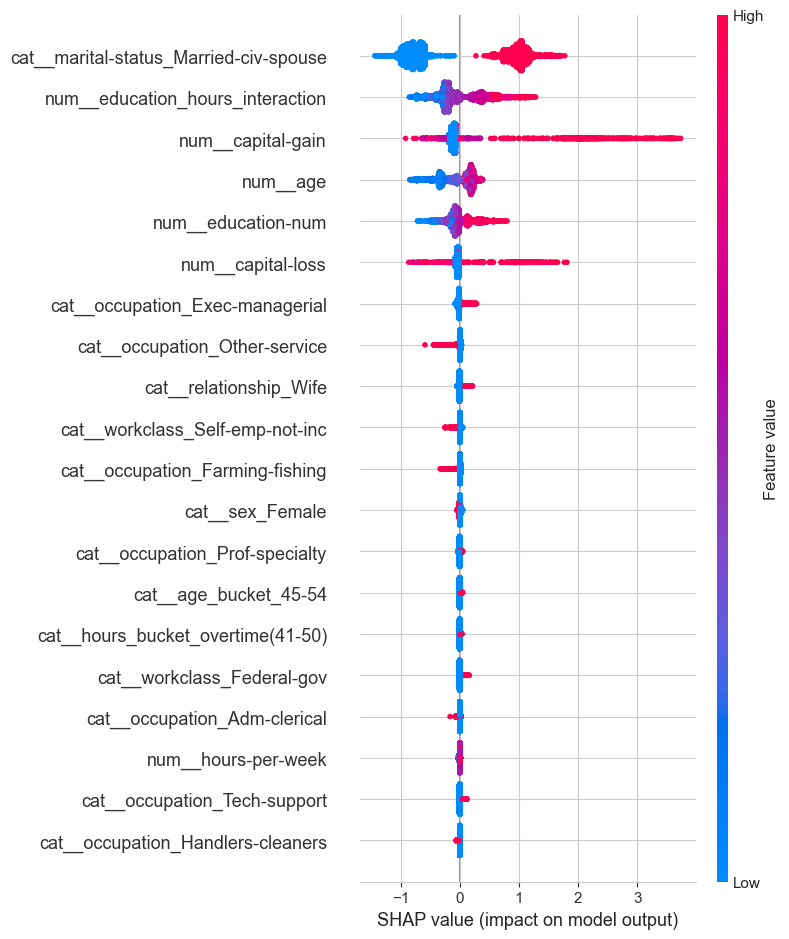

In [152]:
shap.summary_plot(

    shap_values,

    X_test_processed,

    feature_names=feature_names

)

### Interpretation

The SHAP summary plot provides a global view of both feature importance and the direction of each feature's influence on model predictions. Higher values of **capital gain**, **education**, and the engineered **education_hours_interaction** feature generally pushed predictions toward the high-income class. Conversely, lower values of these features reduced the predicted probability of belonging to the positive class. The strong importance of the engineered interaction feature further validates the effectiveness of the feature engineering performed during model development.

### Overall Top Features

Across the three interpretability methods, the following features consistently emerged as the most influential predictors:

1. Capital Gain
2. Capital Loss
3. Age
4. Education Number
5. Education-Hours Interaction *(Engineered Feature)*
6. Marital Status
7. Executive Managerial Occupation
8. Other-Service Occupation

The agreement between the three interpretability techniques provides confidence that these variables are the primary drivers of the model's predictions.

### Part 2 — Local Interpretability

To better understand individual predictions, SHAP waterfall plots were generated for three representative test instances:

- A **True Positive (TP)**, where the model correctly predicted a high-income individual.
- A **False Positive (FP)**, where the model incorrectly predicted a high-income individual.
- A **False Negative (FN)**, where the model failed to identify a high-income individual.

Each plot illustrates how individual features contributed positively or negatively to the final prediction.

In [153]:
# create predictions
y_pred = lgbm_pipeline.predict(X_test)

In [155]:
# find TP, FP, FN

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]

fp_idx = np.where((y_test == 0) & (y_pred == 1))[0][0]

fn_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

print(tp_idx, fp_idx, fn_idx)

6 2 4


### Waterfall Plot

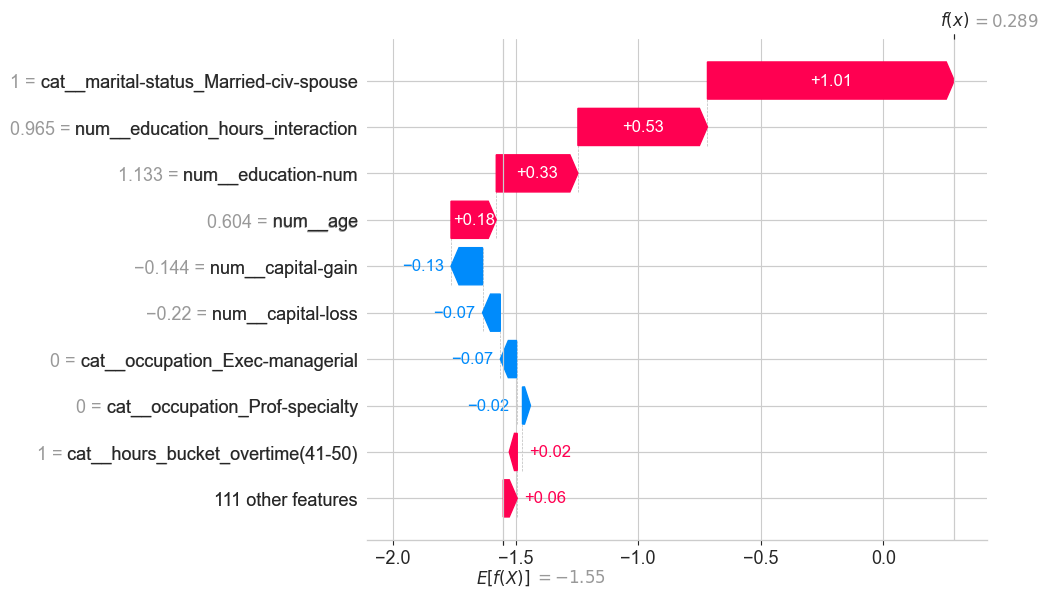

In [156]:
# TP
shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[tp_idx],

        base_values=explainer.expected_value,

        data=X_test_processed[tp_idx],

        feature_names=feature_names

    )

)

### True Positive

The model correctly classified this individual as belonging to the high-income class. Being **married**, having a relatively **high education-hours interaction**, and a higher **education level** were the strongest positive contributors to the prediction. These positive factors outweighed smaller negative contributions, resulting in a confident positive classification.

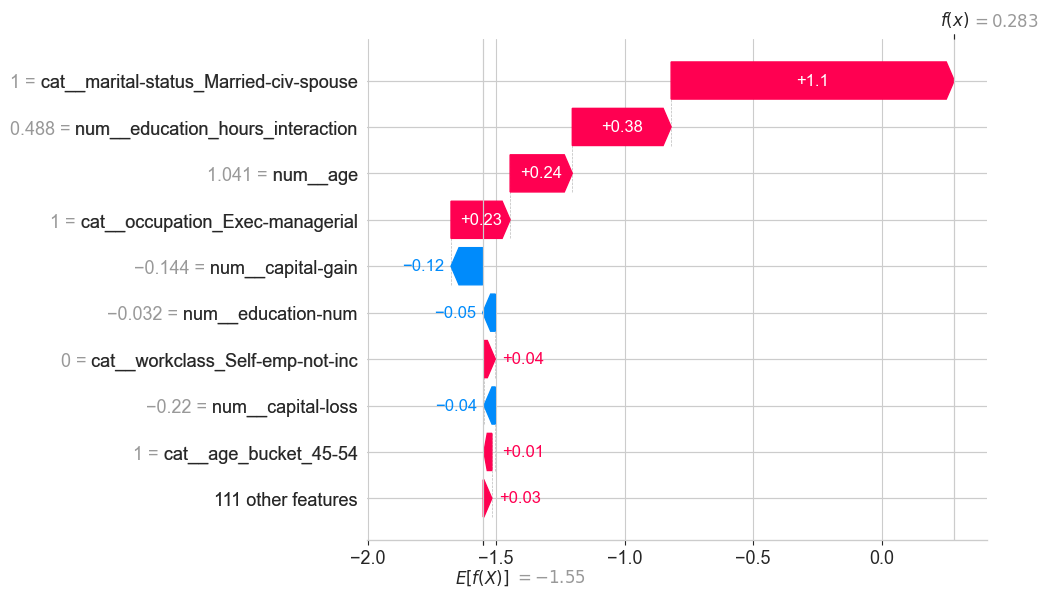

In [157]:
# FP
shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[fp_idx],

        base_values=explainer.expected_value,

        data=X_test_processed[fp_idx],

        feature_names=feature_names

    )

)

### False Positive

For this individual, the model predicted the high-income class even though the true label was negative. Strong positive signals such as **marital status**, **education-hours interaction**, and **age** outweighed weaker negative factors, causing the model to overestimate the probability of high income. This illustrates how influential socioeconomic features can occasionally lead to incorrect positive predictions.

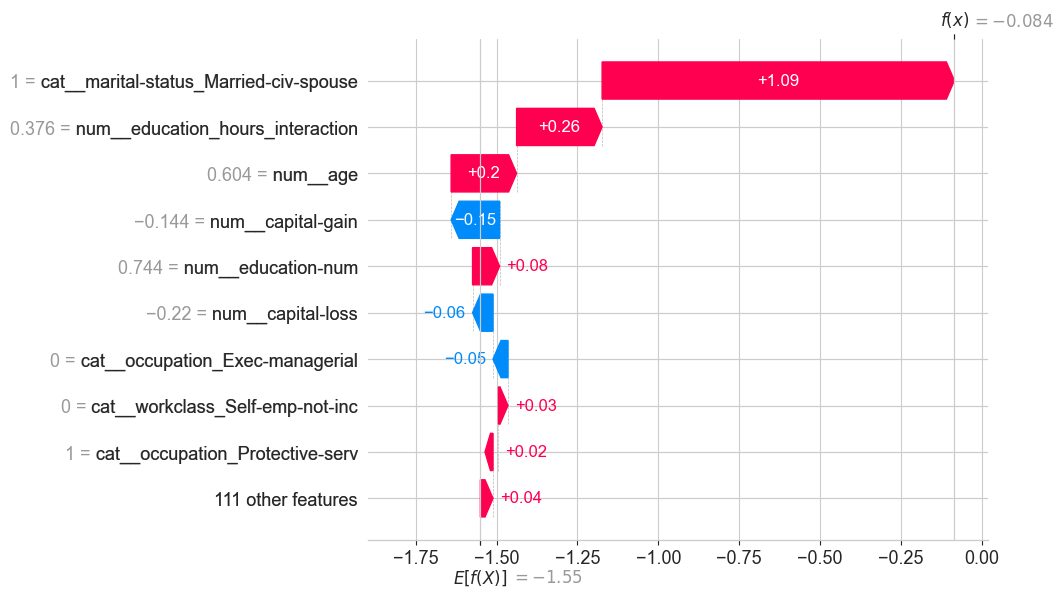

In [158]:
# FN
shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[fn_idx],

        base_values=explainer.expected_value,

        data=X_test_processed[fn_idx],

        feature_names=feature_names

    )

)

### False Negative

In this case, the model incorrectly classified a high-income individual as belonging to the negative class. Although several features, including **marital status** and **education-hours interaction**, contributed positively, these effects were insufficient to overcome the stronger negative contributions. This resulted in the model underestimating the individual's probability of belonging to the high-income class.

### Part 3 — Fairness Analysis
To evaluate whether model performance was consistent across demographic groups, the primary business metric (**precision**) was computed separately for protected attributes, including **sex** and **race**.

In [159]:
fairness_df = X_test.copy()

fairness_df["Actual"] = y_test.values

fairness_df["Prediction"] = y_pred

### - Sex

In [160]:
sex_results = []

for sex in fairness_df["sex"].unique():

    subset = fairness_df[
        fairness_df["sex"] == sex
    ]

    precision = precision_score(

        subset["Actual"],

        subset["Prediction"],

        zero_division=0

    )

    sex_results.append({

        "Sex": sex,

        "Precision": precision,

        "Samples": len(subset)

    })

pd.DataFrame(sex_results)

,Sex,Precision,Samples
0,Female,0.879581,3259
1,Male,0.821402,6510


### Interpretation by Sex

The model achieved a precision of **87.96%** for females and **82.14%** for males. Although a small performance gap exists, both groups achieved relatively high precision, suggesting that the model performs consistently across sex without substantial disparities.

### - Race

In [161]:
race_results = []

for race in fairness_df["race"].unique():

    subset = fairness_df[
        fairness_df["race"] == race
    ]

    precision = precision_score(

        subset["Actual"],

        subset["Prediction"],

        zero_division=0

    )

    race_results.append({

        "Race": race,

        "Precision": precision,

        "Samples": len(subset)

    })

pd.DataFrame(race_results)

,Race,Precision,Samples
0,Black,0.902778,968
1,White,0.830935,8312
2,Asian-Pac-Islander,0.680556,311
3,Other,1.000000,82
4,Amer-Indian-Eskimo,1.000000,96


### Interpretation by Race

Precision varied across racial groups, with the highest values observed for the **Other** and **Amer-Indian-Eskimo** categories. However, these groups contain relatively few test samples, making their estimates less reliable. Among the larger demographic groups, **Black** individuals achieved slightly higher precision than **White** individuals, while **Asian-Pac-Islander** exhibited noticeably lower precision. Although these differences suggest some variation in performance across racial groups, additional evaluation using larger and more balanced datasets would be required before drawing definitive conclusions.

### Fairness Conclusion

Overall, the fairness analysis indicates that the model performs reasonably consistently across demographic groups, although some variation exists between racial categories. These differences may be influenced by unequal group representation within the dataset rather than systematic model bias alone.

Potential mitigation strategies include:

- Collecting more representative training data for underrepresented demographic groups.
- Monitoring fairness metrics throughout model development and deployment.
- Evaluating additional fairness measures, such as equal opportunity or demographic parity.
- Applying fairness-aware learning or post-processing techniques if significant disparities are observed in future evaluations.

## Task 4: End-to-End Inference & Basic Monitoring

_The implementation of the inference pipeline and its unit tests is provided in the following files:_
- feature_engineering.py
- inference.py
- inference_test.py
- task4_monitoring_checklist.pdf

## Task 5: Final Deliverables
_The report is attached: `executive_report.pdf`_

### Presentation Outline (5–7 Minutes)

### Slide 1: Project Overview
- Business problem: Predict whether an individual's annual income exceeds \$50,000.
- Dataset: UCI Adult Income Dataset (48,842 records).
- Business objective: Develop an accurate and interpretable machine learning model with an emphasis on precision.

---

### Slide 2: Data Preparation & Feature Engineering
- Data preprocessing and train/dev/test split (70% / 10% / 20%).
- Engineered eight additional features:
  - Age buckets
  - Hours-worked buckets
  - Capital gain/loss indicators
  - Log-transformed capital gain/loss
  - Higher education indicator
  - Education × Hours interaction
- Integrated feature engineering into a reusable preprocessing pipeline.

---

### Slide 3: Model Development
- Evaluated multiple models:
  - Logistic Regression
  - Random Forest
  - LightGBM
  - Stacking Ensemble
- Performed hyperparameter tuning using RandomizedSearchCV.
- Applied probability calibration to the final LightGBM model.

---

### Slide 4: Results & Threshold Selection
- Final model: Calibrated LightGBM.
- Hold-out performance:
  - Accuracy: 86.72%
  - Precision: 79.49%
  - Recall: 60.01%
  - F1-score: 68.39%
  - ROC-AUC: 0.9198
  - PR-AUC: 0.7988
- Selected a decision threshold of **0.45** to achieve at least **75% precision** while maximizing recall.

---

### Slide 5: Interpretability & Fairness
- Global explanations:
  - Feature Importance
  - Permutation Importance
  - SHAP Summary Plot
- Local explanations using SHAP waterfall plots:
  - True Positive
  - False Positive
  - False Negative
- Fairness analysis across sex and race groups, with observed disparities documented and recommendations for ongoing monitoring.

---

### Slide 6: Deployment & Future Work
- Built an end-to-end inference pipeline with:
  - Saved model
  - Input validation
  - Prediction probabilities
  - Custom threshold
  - Top-3 feature contributions
- Implemented unit tests and a monitoring checklist.
- Future work:
  - Continuous model monitoring
  - Periodic retraining
  - Expanded fairness evaluation
  - A/B testing before production deployment.